In [1]:
%load_ext autoreload
%autoreload 2

In [27]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [ ]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME
)

In [4]:
nlp = spacy.blank("es")

In [5]:
json_paths  = glob.glob(f'{BASE_PATH}**/cleaned.json', recursive=True)

In [34]:
json_paths[0]

'data/loc/sn90070270/1897/03/03/ed-1/seq-1/cleaned.json'

In [6]:
len(json_paths)

158121

In [8]:
target_words = set(JIBARO_WORDS + GIBARO_WORDS + CAMPESINO_WORDS)

In [9]:
word_index = defaultdict(list)
text_block_map = {}
paper_data = []

keys_to_copy = ['lccn', 'date', 'year', 'month', 'day', 'edition', 'sequence', 'link']
for path in tqdm(json_paths):
    try:
        with open(path, 'r') as f:
            d = json.load(f)
            dd = {k: d[k] for k in keys_to_copy}
            total_tokens = 0
            for i, tb in enumerate(d['text_blocks_cleaned']):
                text_block_map[(i, d['link'])] = tb['text']
                for tok in nlp(tb['text']):
                    total_tokens += 1 
                    if tok.text.lower() in target_words:
                        word_index[tok.text.lower()].append((i, d['link']))
            dd['total_tokens'] = total_tokens
            paper_data.append(dd)
    except json.JSONDecodeError as e:
        # Handle the specific error if decoding fails
        print("Error: Unable to decode JSON.")
        print("Details:", e)


 86%|█████████████████████████████████████████████████████████████████████████████████████████▏              | 135650/158121 [28:47<05:26, 68.90it/s]

Error: Unable to decode JSON.
Details: Expecting value: line 1 column 1 (char 0)


 88%|███████████████████████████████████████████████████████████████████████████████████████████▊            | 139574/158121 [29:54<06:52, 44.92it/s]

Error: Unable to decode JSON.
Details: Expecting value: line 1 column 1 (char 0)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 158121/158121 [36:30<00:00, 72.17it/s]


In [10]:
paper_data

[{'lccn': 'sn90070270',
  'date': '1897-03-03',
  'year': '1897',
  'month': '03',
  'day': '03',
  'edition': 'ed-1',
  'sequence': 'seq-1',
  'link': 'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-1/',
  'total_tokens': 3678},
 {'lccn': 'sn90070270',
  'date': '1897-03-03',
  'year': '1897',
  'month': '03',
  'day': '03',
  'edition': 'ed-1',
  'sequence': 'seq-3',
  'link': 'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-3/',
  'total_tokens': 5412},
 {'lccn': 'sn90070270',
  'date': '1897-03-03',
  'year': '1897',
  'month': '03',
  'day': '03',
  'edition': 'ed-1',
  'sequence': 'seq-4',
  'link': 'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-4/',
  'total_tokens': 3474},
 {'lccn': 'sn90070270',
  'date': '1897-03-03',
  'year': '1897',
  'month': '03',
  'day': '03',
  'edition': 'ed-1',
  'sequence': 'seq-2',
  'link': 'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/',
  'total_

In [10]:
dataset_df = pd.DataFrame.from_dict(paper_data)
dataset_df['title'] = dataset_df['lccn'].map(LCCN_TO_NAME)

In [11]:
dataset_df = dataset_df.set_index('link')

In [26]:
dataset_df.to_pickle('prelim_analysis_df.pkl')

In [28]:
with open('word_index.pkl', 'wb') as f:
    pickle.dump(word_index, f)

In [12]:
jibaro_counts = defaultdict(int)
gibaro_counts = defaultdict(int)
campsino_counts = defaultdict(int)
for w in JIBARO_WORDS:
    for _, l in word_index[w]:
        jibaro_counts[l] += 1

for w in GIBARO_WORDS:
    for _, l in word_index[w]:
        gibaro_counts[l] += 1

for w in CAMPESINO_WORDS:
    for _, l in word_index[w]:
        campsino_counts[l] += 1

In [17]:
dataset_df['jibaro_counts'] = [jibaro_counts[i] for i in dataset_df.index]
dataset_df['gibaro_counts'] = [gibaro_counts[i] for i in dataset_df.index]
dataset_df['campsino_counts'] = [campsino_counts[i] for i in dataset_df.index]

dataset_df['contains_search_word_jibar'] = dataset_df['jibaro_counts'] > 0
dataset_df['contains_search_word_gibar'] = dataset_df['gibaro_counts'] > 0
dataset_df['contains_search_word_campesin'] = dataset_df['campsino_counts'] > 0

dataset_df['jibaro_freq'] = dataset_df['jibaro_counts'] / dataset_df['total_tokens']
dataset_df['gibaro_freq'] = dataset_df['gibaro_counts'] / dataset_df['total_tokens']
dataset_df['campesino_freq'] = dataset_df['campsino_counts'] / dataset_df['total_tokens']

In [33]:
dataset_df[dataset_df[['jibaro_counts', 'gibaro_counts', 'campsino_counts']].sum(axis=1) > 0].to_pickle('prelim_analysis_target_records_df.pkl')


In [21]:

import matplotlib.ticker as mtick

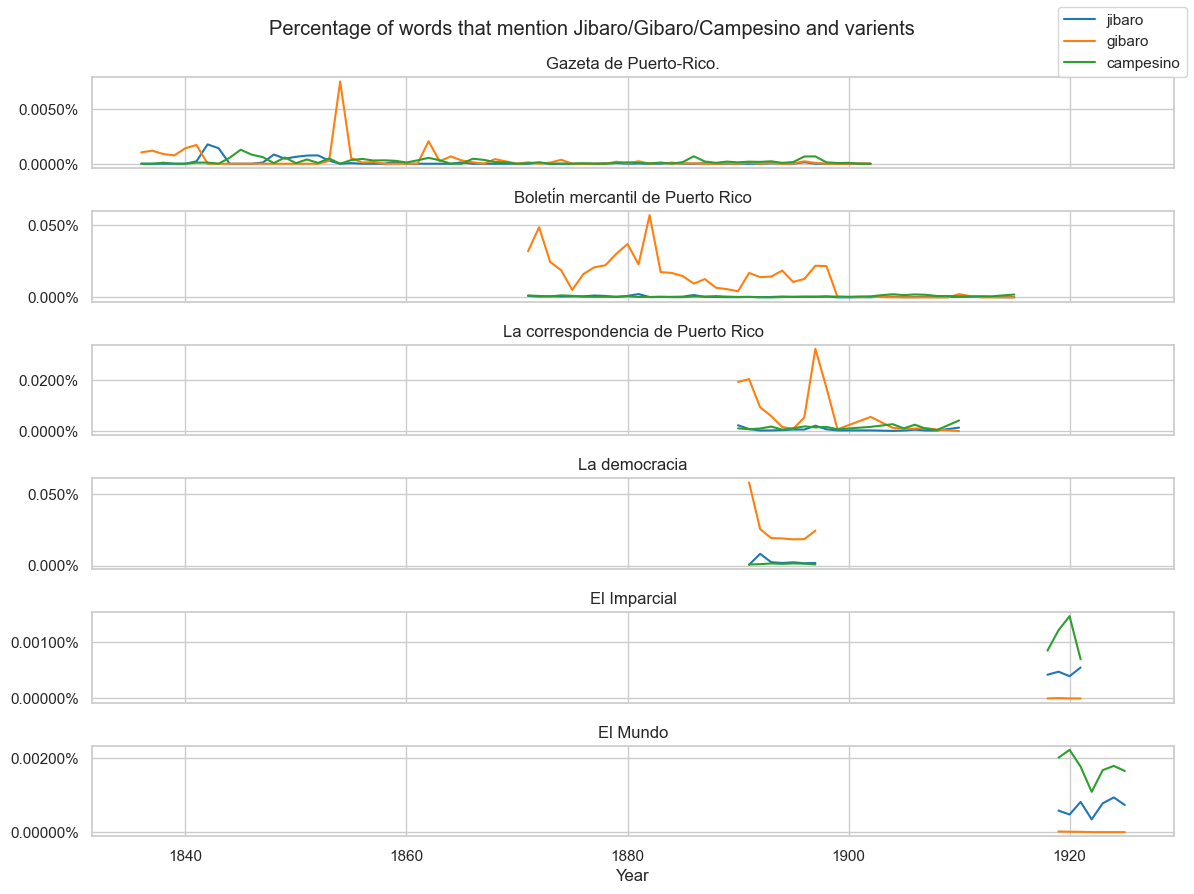

In [25]:
sns.set_theme(style="whitegrid")

# plot_df = (
#     dataset_df
#     .groupby(['year', 'title'])[['jibaro_freq', 'gibaro_freq', 'campesino_freq']]
#     .mean()
#     .reset_index()
# )

plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'jibaro_freq': 'tab:blue',
    'gibaro_freq': 'tab:orange',
    'campesino_freq': 'tab:green'
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['jibaro_freq'],
        color=freq_colors['jibaro_freq'],
        label='jibaro'
    )

    ax.plot(
        df_t['year'],
        df_t['gibaro_freq'],
        color=freq_colors['gibaro_freq'],
        label='gibaro'
    )

    ax.plot(
        df_t['year'],
        df_t['campesino_freq'],
        color=freq_colors['campesino_freq'],
        label='campesino'
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title)
    # ax.set_ylabel("Frequency")

axes[-1].set_xlabel("Year")

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Percentage of words that mention Jibaro/Gibaro/Campesino and varients")
plt.tight_layout()
plt.show()


In [106]:
words = []
for k, v in word_index.items():
    if (len(v) > 5) and len(k) > 5:
        words.append(k)

In [108]:
from rapidfuzz.distance import Levenshtein

def top_n_similar_words(words, target_word, n=10):
    """
    Returns a list of (word, distance) sorted by smallest Levenshtein distance.
    """
    scored = [
        (w, Levenshtein.distance(target_word, w))
        for w in words
    ]

    # smallest distance = most similar
    scored.sort(key=lambda x: x[1])
    return scored[:n]

In [115]:
top_n_similar_words(words, 'jibaritos')

[('jibarito', 1),
 ('jibaros', 2),
 ('libritos', 2),
 ('baratos', 3),
 ('barios', 3),
 ('jíbaros', 3),
 ('distritos', 3),
 ('diarios', 3),
 ('garitos', 3),
 ('cialitos', 3)]

In [114]:
top_n_similar_words(words, 'jibaro')

[('jibarito', 1),
 ('jibaros', 2),
 ('libritos', 2),
 ('baratos', 3),
 ('barios', 3),
 ('jíbaros', 3),
 ('distritos', 3),
 ('diarios', 3),
 ('garitos', 3),
 ('cialitos', 3)]

In [110]:
top_n_similar_words(words, 'gibara')

[('gibara', 0),
 ('jibara', 1),
 ('gribara', 1),
 ('libara', 1),
 ('gib&ra', 1),
 ('qibara', 1),
 ('sibara', 1),
 ('iibara', 1),
 ('girara', 1),
 ('oibara', 1)]

In [116]:
top_n_similar_words(words, 'campesin')

[('campesino', 1),
 ('campesi', 1),
 ('campesina', 1),
 ('campesinos', 2),
 ('campes', 2),
 ('campeón', 2),
 ('campesinas', 2),
 ('campean', 2),
 ('competir', 3),
 ('campos', 3)]

In [96]:
print(text_block_map[(111,
  'https://chroniclingamerica.loc.gov/lccn/2013201074/1855-05-22/ed-1/seq-4/')])

' entradas y salidas de buques.
Entradas. n 1
15. No hubo.
16. De Baltimore, gol. amer. Alice Mowe, cap. L.
S. Pike, con provisiones. "
De Génova, en 46 dias, berg. ing. Violet, capitán Pedro Alien, en lastre...i
17. De Málaga, poles. Amelia, cap. D. Pedro Ber
trán, con frutos. (
üe Barcelona y Valencia, polacra-goleta id. Coruñesa, cap. D. Eusebio Fábregas, con id.
Ue Gibara, y comunicado en Santo Uomingo,
en, 22 dias, gol. id. Otilia, cap. U. Vicente Pérez,
con tabaco. - ...
18. De Santomas, id. id. Esperanza, cap. D. Juan
Salas, con mercancías y efectos.
De Santiago de Cuba, en 19 dias, gol. id. Triunfo, cap. I). Julián Morales, con tabaco y efectos.
De Pon... y Coamo, id. id. Sirena, pal. Ü. Vicente Riera, con efectos del pais.
De la Bermuda. en 9 dias, id. ing. E. O. Bigelaw, cap. W. Whitter, con salazón y frutos.
. Salidas.
15. Para Fajardo, gol. esp. Jóven Benita, pft. Hila-


In [158]:
word_index['jíbaro']

[(21,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/'),
 (200,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-27/ed-1/seq-3/'),
 (103,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-29/ed-1/seq-3/'),
 (2,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-31/ed-1/seq-3/'),
 (5,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-31/ed-1/seq-2/'),
 (5,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-31/ed-1/seq-2/'),
 (3,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-30/ed-1/seq-3/'),
 (139,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-12/ed-1/seq-3/'),
 (255,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-22/ed-1/seq-3/'),
 (42,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-04-02/ed-1/seq-3/'),
 (17,
  'https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-04-02/ed-1/seq-2/'),
 (19,
  'https://chroniclingamerica.loc.gov/lccn/sn900

In [52]:
'jíbaras' in word_index.keys()

False

In [7]:
d['text_blocks_cleaned']

[{'id': 'TB.0055b.1',
  'height': '60',
  'width': '52',
  'hpos': '5080',
  'vpos': '584',
  'text': 'V'},
 {'id': 'TB.0055b.2',
  'height': '488',
  'width': '11824',
  'hpos': '2816',
  'vpos': '2264',
  'text': 'Nü SABADO 8 dia-jffarzrt nrc ir. Ví)I'},
 {'id': 'TB.0055b.3',
  'height': '280',
  'width': '2608',
  'hpos': '14648',
  'vpos': '2488',
  'text': ''},
 {'id': 'TB.0055b.4',
  'height': '104',
  'width': '80',
  'hpos': '1096',
  'vpos': '21648',
  'text': ''},
 {'id': 'TB.0055b.5',
  'height': '5420',
  'width': '15412',
  'hpos': '1504',
  'vpos': '2808',
  'text': 'irijltl rni-fiiití .mil í-if. fn ..Ini M .ir" : f,ni!,ií,i-ií...,) ... \' , i\nti T ;.i i -i. ( ......i , i... .(,a 1.º..., llmsm .....................jíá;?zr" , "V"... t i... -:i\nOti. .P al E llwk ....-"ííí tul t. ...1.º\nmí-üv-&\'íi , MSI Jmjm Wj n\n... al u.ti.w.i..y... ... ... r... ,lík \' ... 1 \' ni"'},
 {'id': 'TB.0055b.6',
  'height': '248',
  'width': '15456',
  'hpos': '1472',
  'vpos': '8224',
  '